In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("walmart_sales.csv")

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Data_Clean,Year,Month,Month Name,Quarter,Week Number,Holiday Status
0,1,5/2/2010,"$1,643,691",0,42.31,2.572,211.0964,8.106,5/2/2010,2010,5,May,Q2,18,Non-Holiday
1,1,12/2/2010,"$1,641,957",1,38.51,2.548,211.2422,8.106,12/2/2010,2010,12,December,Q4,49,Holiday
2,1,19-02-2010,"$1,611,968",0,39.93,2.514,211.2891,8.106,2/19/2010,2010,2,February,Q1,8,Non-Holiday
3,1,26-02-2010,"$1,409,728",0,46.63,2.561,211.3196,8.106,2/26/2010,2010,2,February,Q1,9,Non-Holiday
4,1,5/3/2010,"$1,554,807",0,46.50,2.625,211.3501,8.106,5/3/2010,2010,5,May,Q2,19,Non-Holiday


In [7]:
df = pd.read_csv("walmart_sales.csv")

df.columns = df.columns.str.strip()

df = df.drop(columns=[
    "Data_Clean", "Year", "Month", "Month Name", "Quarter",
    "Week Number", "Holiday Status", "Month_Name",
    "Week_Number", "Holiday_Status"
], errors="ignore")

df["Weekly_Sales"] = (
    df["Weekly_Sales"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Data_Clean"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df["Year"] = df["Data_Clean"].dt.year
df["Month"] = df["Data_Clean"].dt.month
df["Month_Name"] = df["Data_Clean"].dt.month_name()
df["Quarter"] = "Q" + df["Data_Clean"].dt.quarter.astype(str)
df["Week_Number"] = df["Data_Clean"].dt.isocalendar().week

df["Holiday_Status"] = df["Holiday_Flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

In [8]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Data_Clean,Year,Month,Month_Name,Quarter,Week_Number,Holiday_Status
0,1,5/2/2010,1643691.0,0,42.31,2.572,211.0964,8.106,2010-02-05,2010,2,February,Q1,5,Non-Holiday
1,1,12/2/2010,1641957.0,1,38.51,2.548,211.2422,8.106,2010-02-12,2010,2,February,Q1,6,Holiday
2,1,19-02-2010,1611968.0,0,39.93,2.514,211.2891,8.106,2010-02-19,2010,2,February,Q1,7,Non-Holiday
3,1,26-02-2010,1409728.0,0,46.63,2.561,211.3196,8.106,2010-02-26,2010,2,February,Q1,8,Non-Holiday
4,1,5/3/2010,1554807.0,0,46.50,2.625,211.3501,8.106,2010-03-05,2010,3,March,Q1,9,Non-Holiday


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Store           6435 non-null   int64         
 1   Date            6435 non-null   object        
 2   Weekly_Sales    6435 non-null   float64       
 3   Holiday_Flag    6435 non-null   int64         
 4   Temperature     6435 non-null   float64       
 5   Fuel_Price      6435 non-null   float64       
 6   CPI             6435 non-null   float64       
 7   Unemployment    6435 non-null   float64       
 8   Data_Clean      6435 non-null   datetime64[ns]
 9   Year            6435 non-null   int32         
 10  Month           6435 non-null   int32         
 11  Month_Name      6435 non-null   object        
 12  Quarter         6435 non-null   object        
 13  Week_Number     6435 non-null   UInt32        
 14  Holiday_Status  6435 non-null   object        
dtypes: U

In [10]:
df.isnull().sum()

Store             0
Date              0
Weekly_Sales      0
Holiday_Flag      0
Temperature       0
Fuel_Price        0
CPI               0
Unemployment      0
Data_Clean        0
Year              0
Month             0
Month_Name        0
Quarter           0
Week_Number       0
Holiday_Status    0
dtype: int64

In [12]:
# ===============================
#  Basic KPIs
# ===============================

total_sales = df["Weekly_Sales"].sum()
avg_weekly_sales = df["Weekly_Sales"].mean()
total_stores = df["Store"].nunique()
total_rows = df.shape[0]
start_date = df["Data_Clean"].min()
end_date = df["Data_Clean"].max()

print("Total Sales:", total_sales)
print("Average Weekly Sales:", avg_weekly_sales)
print("Total Stores:", total_stores)
print("Total Rows:", total_rows)
print("Start Date:", start_date)
print("End Date:", end_date)

Total Sales: 6737219008.0
Average Weekly Sales: 1046964.8808080808
Total Stores: 45
Total Rows: 6435
Start Date: 2010-02-05 00:00:00
End Date: 2012-10-26 00:00:00


In [13]:
# ===============================
# Sales Summary
# ===============================

sales_summary = df["Weekly_Sales"].describe()

sales_summary

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099860e+05
25%      5.533500e+05
50%      9.607460e+05
75%      1.420158e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

In [14]:
# ===============================
#  Total Sales by Store
# ===============================

sales_by_store = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sales_by_store.head(10)

,Store,Weekly_Sales
0,20,301397795.0
1,4,299543953.0
2,14,288999911.0
3,13,286517707.0
4,2,275382441.0
5,10,271617714.0
6,27,253855919.0
7,6,223756129.0
8,1,222402813.0
9,39,207445548.0


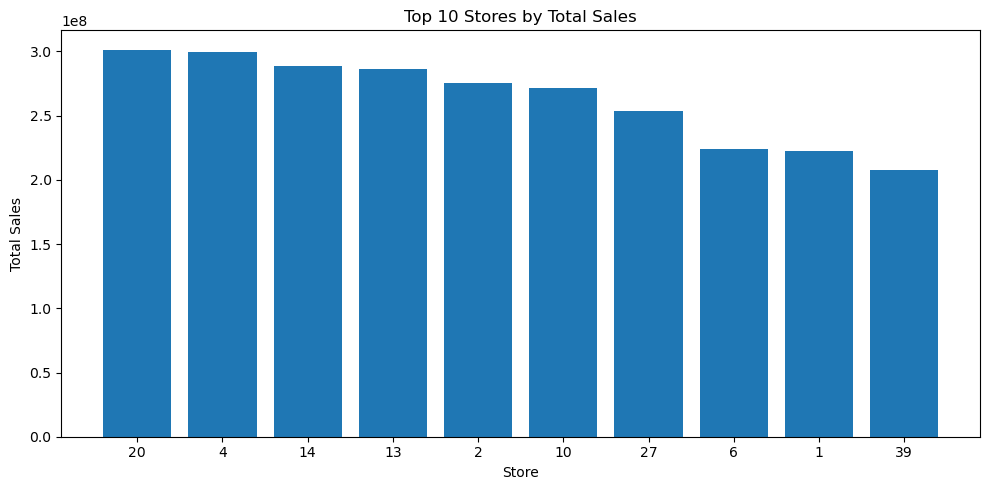

In [15]:
# ===============================
#  Top 10 Stores Chart
# ===============================

top_10_stores = sales_by_store.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_10_stores["Store"].astype(str), top_10_stores["Weekly_Sales"])
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# ===============================
#  Bottom 10 Stores
# ===============================

bottom_10_stores = sales_by_store.tail(10)

bottom_10_stores

,Store,Weekly_Sales
35,29,77141555.0
36,16,74252428.0
37,37,74202741.0
38,30,62716890.0
39,3,57586736.0
40,38,55159625.0
41,36,53412217.0
42,5,45475698.0
43,44,43293082.0
44,33,37160223.0


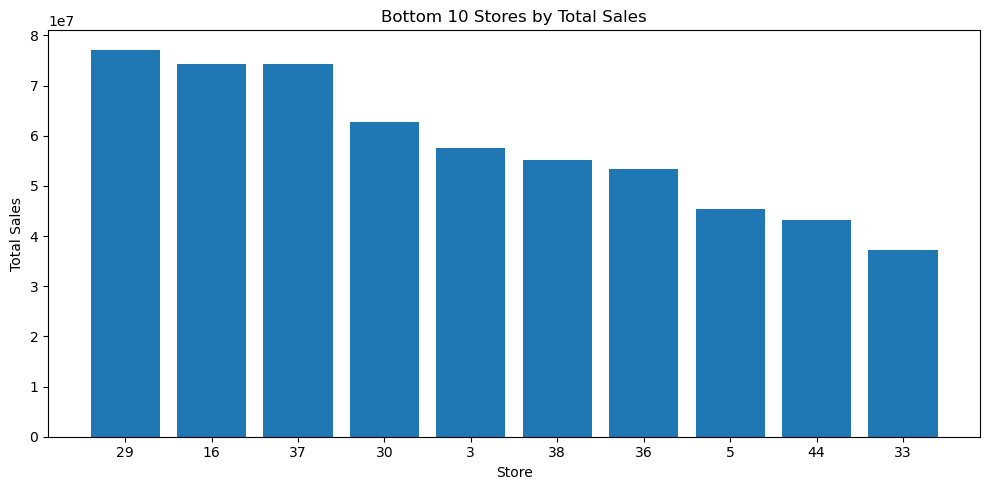

In [17]:
# ===============================
#  Bottom 10 Stores Chart
# ===============================

plt.figure(figsize=(10, 5))
plt.bar(bottom_10_stores["Store"].astype(str), bottom_10_stores["Weekly_Sales"])
plt.title("Bottom 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# ===============================
#  Sales by Year
# ===============================

sales_by_year = (
    df.groupby("Year")["Weekly_Sales"]
    .sum()
    .reset_index()
)

sales_by_year

,Year,Weekly_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


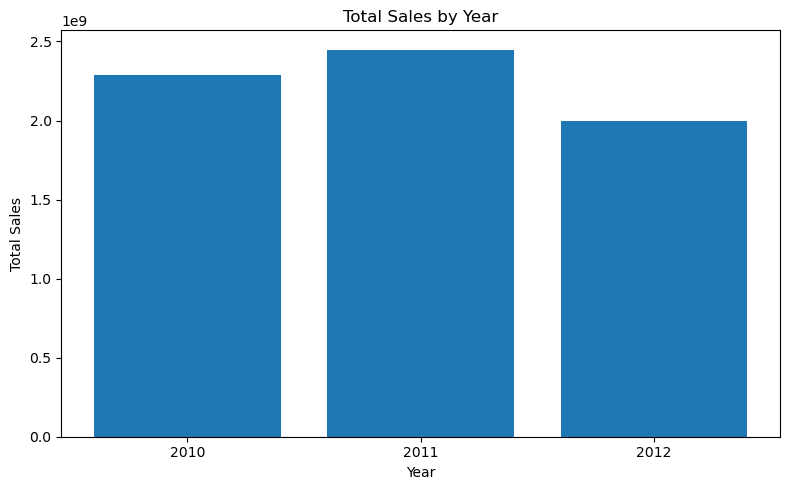

In [19]:
# ===============================
#  Sales by Year Chart
# ===============================

plt.figure(figsize=(8, 5))
plt.bar(sales_by_year["Year"].astype(str), sales_by_year["Weekly_Sales"])
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [20]:
# ===============================
#  Sales by Month
# ===============================

sales_by_month = (
    df.groupby(["Month", "Month_Name"])["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

sales_by_month

,Month,Month_Name,Weekly_Sales
0,1,January,332598442.0
1,2,February,568727899.0
2,3,March,592785890.0
3,4,April,646859784.0
4,5,May,557125577.0
5,6,June,622629888.0
6,7,July,650000982.0
7,8,August,613090214.0
8,9,September,578761186.0
9,10,October,584784778.0


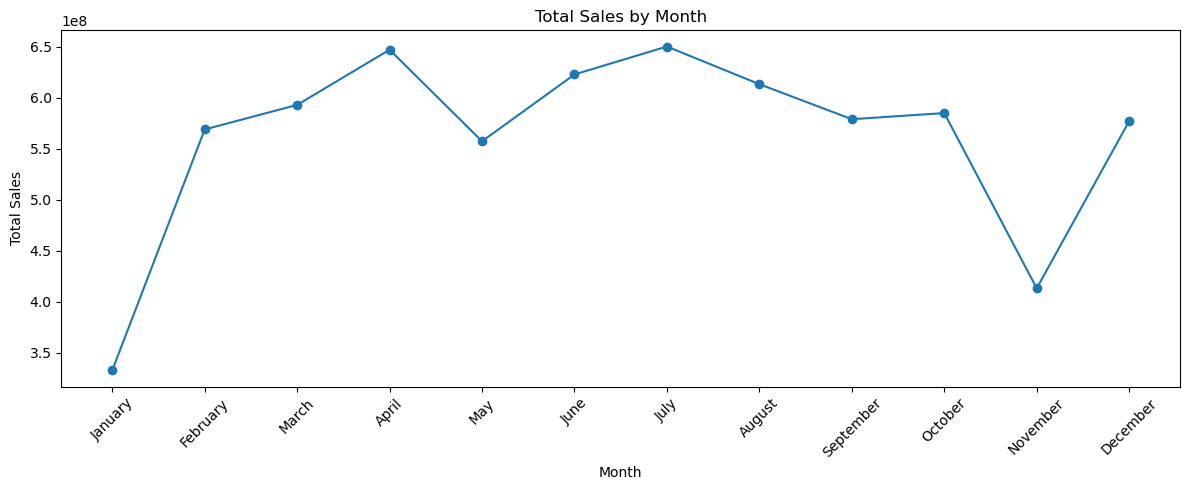

In [21]:
# ===============================
#  Sales by Month Chart
# ===============================

plt.figure(figsize=(12, 5))
plt.plot(sales_by_month["Month_Name"], sales_by_month["Weekly_Sales"], marker="o")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# ===============================
#  Sales by Year and Month
# ===============================

sales_by_year_month = (
    df.groupby(["Year", "Month", "Month_Name"])["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

sales_by_year_month

,Year,Month,Month_Name,Weekly_Sales
0,2010,2,February,190332986.0
1,2010,3,March,181919798.0
2,2010,4,April,231412370.0
3,2010,5,May,186710937.0
4,2010,6,June,192246177.0
5,2010,7,July,232580128.0
6,2010,8,August,187640109.0
7,2010,9,September,177267899.0
8,2010,10,October,217161819.0
9,2010,11,November,202853374.0


In [23]:
# ===============================
#  Sales Trend by Date
# ===============================

sales_trend = (
    df.groupby("Data_Clean")["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values("Data_Clean")
)

sales_trend.head()

,Data_Clean,Weekly_Sales
0,2010-02-05,49750741.0
1,2010-02-12,48336676.0
2,2010-02-19,48276997.0
3,2010-02-26,43968572.0
4,2010-03-05,46871470.0


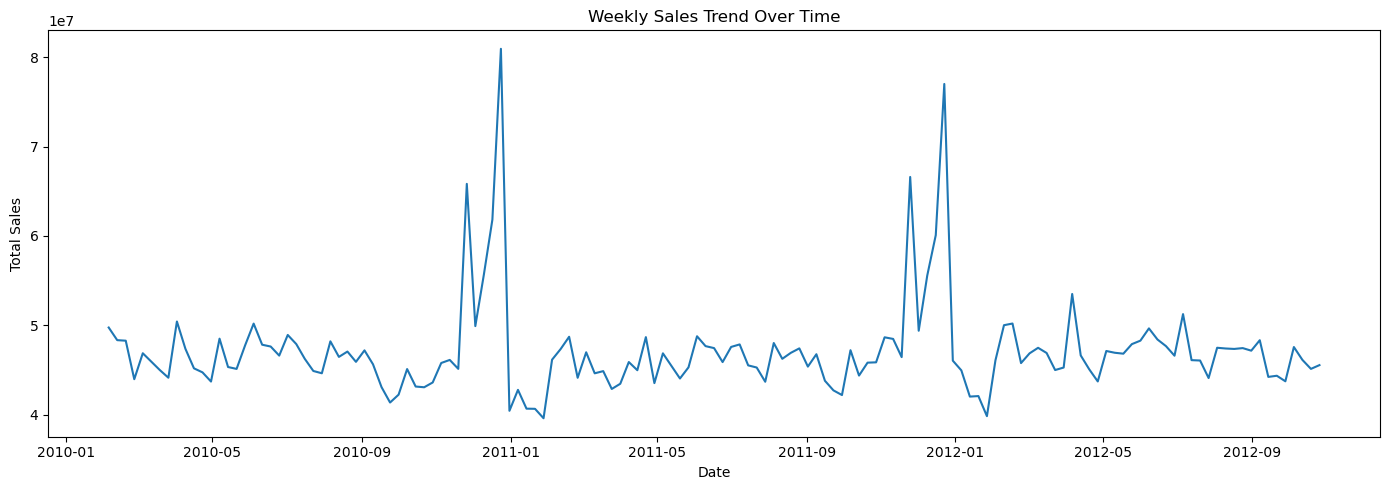

In [24]:
# ===============================
#  Sales Trend Chart
# ===============================

plt.figure(figsize=(14, 5))
plt.plot(sales_trend["Data_Clean"], sales_trend["Weekly_Sales"])
plt.title("Weekly Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [25]:
# ===============================
#  Holiday vs Non-Holiday Sales
# ===============================

holiday_sales = (
    df.groupby("Holiday_Status")["Weekly_Sales"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)

holiday_sales

,Holiday_Status,sum,mean,count
0,Holiday,5.052996e+08,1.122888e+06,450
1,Non-Holiday,6.231919e+09,1.041256e+06,5985


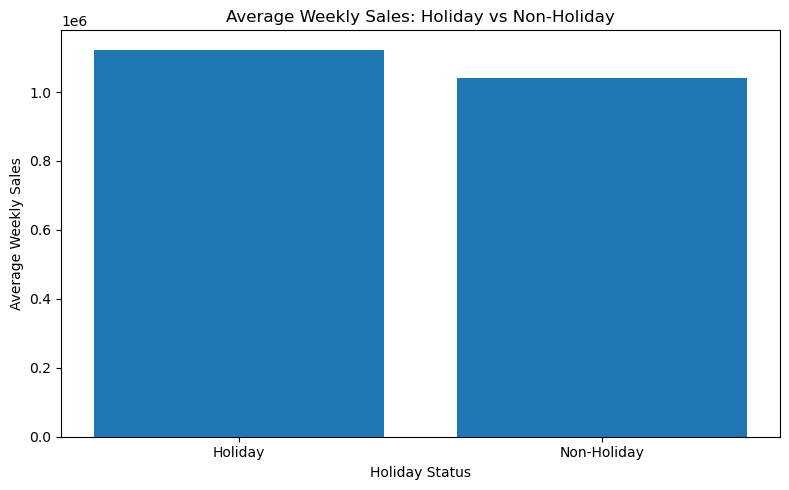

In [26]:
# ===============================
#  Holiday vs Non-Holiday Chart
# ===============================

plt.figure(figsize=(8, 5))
plt.bar(holiday_sales["Holiday_Status"], holiday_sales["mean"])
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Status")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

In [27]:
# ===============================
#  Sales by Quarter
# ===============================

sales_by_quarter = (
    df.groupby("Quarter")["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values("Quarter")
)

sales_by_quarter

,Quarter,Weekly_Sales
0,Q1,1.494112e+09
1,Q2,1.826615e+09
2,Q3,1.841852e+09
3,Q4,1.574639e+09


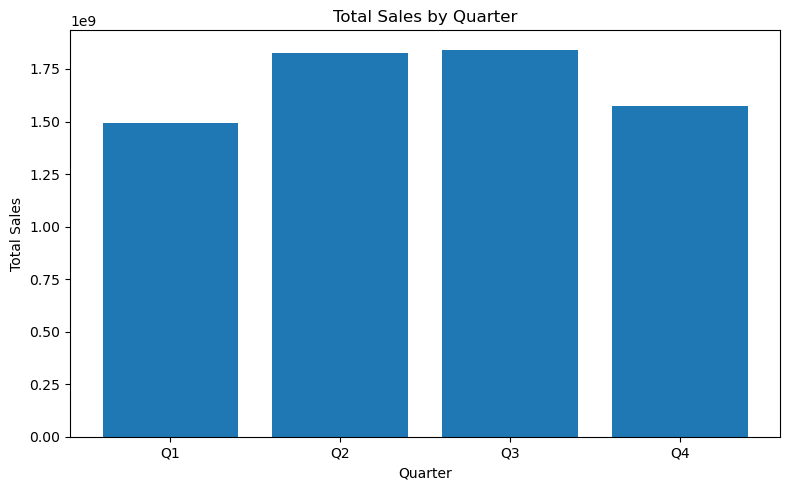

In [28]:
# ===============================
#  Sales by Quarter Chart
# ===============================

plt.figure(figsize=(8, 5))
plt.bar(sales_by_quarter["Quarter"], sales_by_quarter["Weekly_Sales"])
plt.title("Total Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [29]:
# ===============================
#  Correlation
# ===============================

correlation_data = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]].corr()

correlation_data

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,-0.063810,0.009464,-0.072634,-0.106176
Temperature,-0.063810,1.000000,0.144982,0.176888,0.101158
Fuel_Price,0.009464,0.144982,1.000000,-0.170642,-0.034684
CPI,-0.072634,0.176888,-0.170642,1.000000,-0.302020
Unemployment,-0.106176,0.101158,-0.034684,-0.302020,1.000000


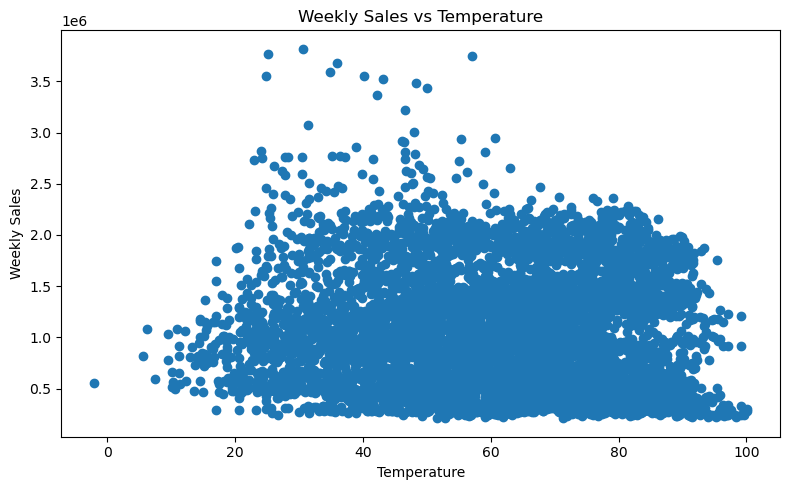

In [30]:
# ===============================
#  Weekly Sales vs Temperature
# ===============================

plt.figure(figsize=(8, 5))
plt.scatter(df["Temperature"], df["Weekly_Sales"])
plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

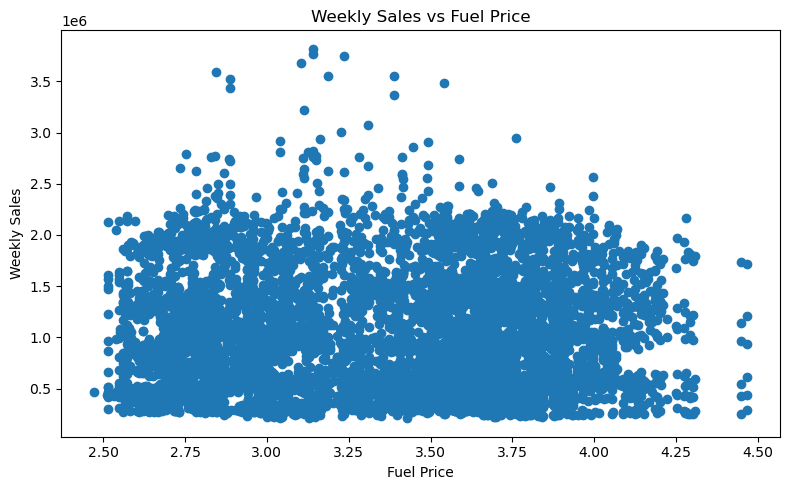

In [31]:
# ===============================
#  Weekly Sales vs Fuel Price
# ===============================

plt.figure(figsize=(8, 5))
plt.scatter(df["Fuel_Price"], df["Weekly_Sales"])
plt.title("Weekly Sales vs Fuel Price")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

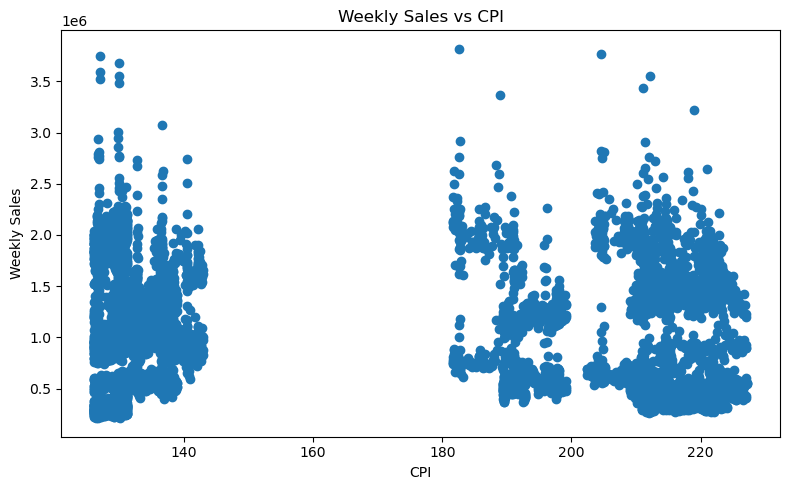

In [32]:
# ===============================
#  Weekly Sales vs CPI
# ===============================

plt.figure(figsize=(8, 5))
plt.scatter(df["CPI"], df["Weekly_Sales"])
plt.title("Weekly Sales vs CPI")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

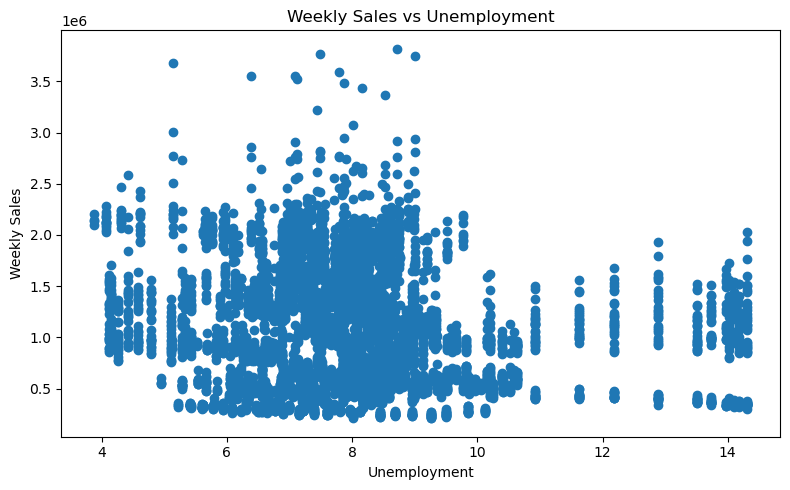

In [33]:
# ===============================
#  Weekly Sales vs Unemployment
# ===============================

plt.figure(figsize=(8, 5))
plt.scatter(df["Unemployment"], df["Weekly_Sales"])
plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

In [34]:
# ===============================
#  Best Month in Each Year
# ===============================

best_month_each_year = (
    sales_by_year_month
    .sort_values(["Year", "Weekly_Sales"], ascending=[True, False])
    .groupby("Year")
    .head(1)
)

best_month_each_year

,Year,Month,Month_Name,Weekly_Sales
10,2010,12,December,288760533.0
22,2011,12,December,288078100.0
28,2012,6,June,240610329.0


In [35]:
# ===============================
#  Best Store in Each Year
# ===============================

store_year_sales = (
    df.groupby(["Year", "Store"])["Weekly_Sales"]
    .sum()
    .reset_index()
)

best_store_each_year = (
    store_year_sales
    .sort_values(["Year", "Weekly_Sales"], ascending=[True, False])
    .groupby("Year")
    .head(1)
)

best_store_each_year

,Year,Store,Weekly_Sales
13,2010,14,105462242.0
48,2011,4,111092290.0
93,2012,4,92771192.0


In [36]:
# ===============================
#  Final Insights
# ===============================

print("Final Insights")
print("--------------")
print("Total Sales:", round(total_sales, 2))
print("Average Weekly Sales:", round(avg_weekly_sales, 2))
print("Best Store:", sales_by_store.iloc[0]["Store"])
print("Best Store Sales:", round(sales_by_store.iloc[0]["Weekly_Sales"], 2))
print("Best Year:", sales_by_year.sort_values("Weekly_Sales", ascending=False).iloc[0]["Year"])
print("Best Month:", sales_by_month.sort_values("Weekly_Sales", ascending=False).iloc[0]["Month_Name"])

Final Insights
--------------
Total Sales: 6737219008.0
Average Weekly Sales: 1046964.88
Best Store: 20.0
Best Store Sales: 301397795.0
Best Year: 2011.0
Best Month: July


In [37]:
# ===============================
#  Export Cleaned Data
# ===============================

df.to_csv("walmart_sales_cleaned_python.csv", index=False)

print("Cleaned file saved successfully.")

Cleaned file saved successfully.


In [41]:
from pathlib import Path

In [42]:
# ===============================
#  Save Important Tables
# ===============================

output_folder = Path("Python_Outputs")
output_folder.mkdir(exist_ok=True)

sales_by_store.to_csv(output_folder / "sales_by_store.csv", index=False)
sales_by_year.to_csv(output_folder / "sales_by_year.csv", index=False)
sales_by_month.to_csv(output_folder / "sales_by_month.csv", index=False)
sales_by_year_month.to_csv(output_folder / "sales_by_year_month.csv", index=False)
holiday_sales.to_csv(output_folder / "holiday_sales.csv", index=False)
sales_by_quarter.to_csv(output_folder / "sales_by_quarter.csv", index=False)
best_month_each_year.to_csv(output_folder / "best_month_each_year.csv", index=False)
best_store_each_year.to_csv(output_folder / "best_store_each_year.csv", index=False)

print("Analysis tables saved successfully.")

Analysis tables saved successfully.


In [43]:
# ===============================
#  Save Charts as Images
# ===============================

charts_folder = Path("Python_Charts")
charts_folder.mkdir(exist_ok=True)

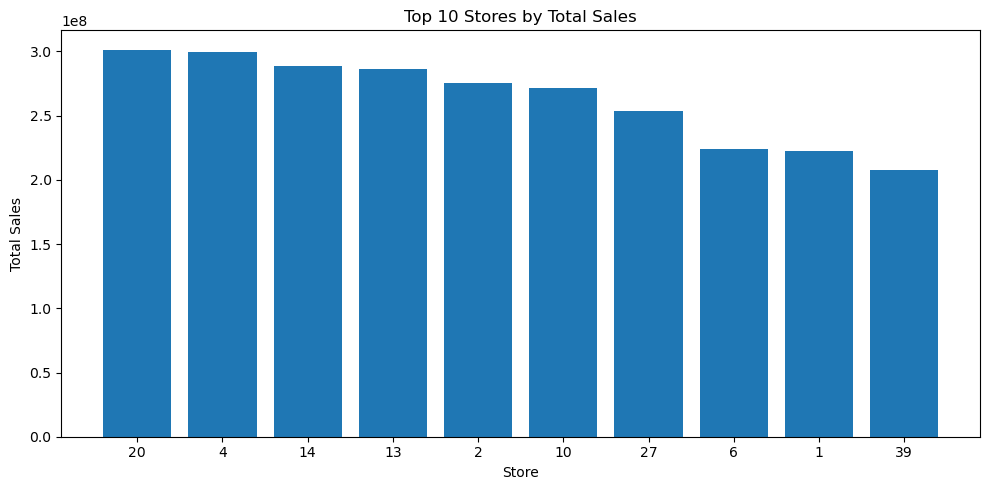

In [44]:
# Top 10 Stores Chart Save

plt.figure(figsize=(10, 5))
plt.bar(top_10_stores["Store"].astype(str), top_10_stores["Weekly_Sales"])
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig(charts_folder / "top_10_stores.png", dpi=300)
plt.show()

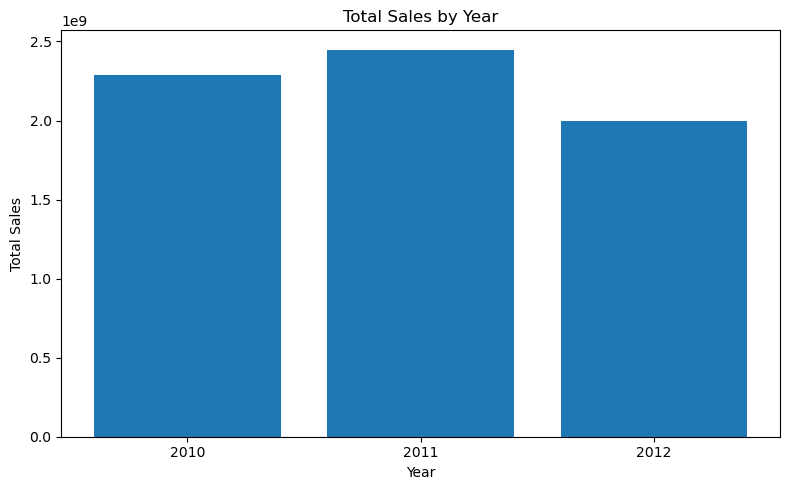

In [45]:
# Sales by Year Chart Save

plt.figure(figsize=(8, 5))
plt.bar(sales_by_year["Year"].astype(str), sales_by_year["Weekly_Sales"])
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig(charts_folder / "sales_by_year.png", dpi=300)
plt.show()

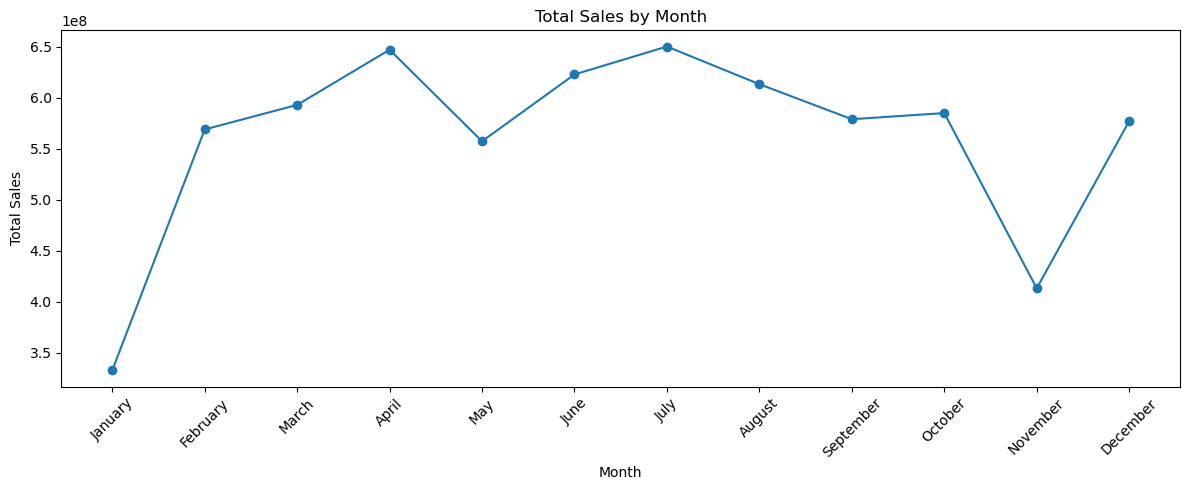

In [46]:
# Sales by Month Chart Save

plt.figure(figsize=(12, 5))
plt.plot(sales_by_month["Month_Name"], sales_by_month["Weekly_Sales"], marker="o")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(charts_folder / "sales_by_month.png", dpi=300)
plt.show()